# `GEA` demo: exploring the DISEASES database

This notebook is used as a demo of GEA's framework on building explainability out of a GNN model trained on disease-associated protein-protein interaction networks.

-----

**Main objectives:**

- Fetch disease-associated gene sets from the [DISEASES](https://diseases.jensenlab.org/) database, and extract their corresponding protein-protein interaction networks for protein-coding genes from the [STRING](https://string-db.org/) database.
- Build the graph dataset doing post-processing of the resulting networks and adding ESM-2 embeddings to each node as feature (this gives each node an unique identity).
- Train a Graph Neural Network (GNN) model on (1) reconstructing the node identity, (2) predicting the interaction score between two nodes, and (3) a semi-supervised contrastive learning objective to group together graphs from the same disease category.
- Building explainability using GEA at the node-, edge- and graph-level embeddings (i.e. training 3 Sparse Autoencoders (SAEs) and attributing features to a known ontology for the genes).

## Fetching data from databases

### Exploring the DISEASES database

#### Setup

In [1]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
DATA_DIR.mkdir(parents=True, exist_ok=True)

#### The DISEASES data

DISEASES publishes one flat file per evidence channel — no API key needed. We use `integrated`, which combines curated knowledge, GWAS and text mining and gives the best gene coverage per disease.

Each row is one (protein, disease) association with a confidence score from 0 (low) to 5 (high) stars.

In [2]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest


DISEASES_URL = "https://download.jensenlab.org/human_disease_integrated_full.tsv"
DISEASES_FILE = download_file(DISEASES_URL, DATA_DIR / "human_disease_integrated_full.tsv")

print(f"{DISEASES_FILE.name}: {DISEASES_FILE.stat().st_size / 1e6:.0f} MB")

human_disease_integrated_full.tsv: 645 MB


The `integrated` channel has five columns and no header row: a STRING protein id, the gene symbol, a Disease Ontology id (DOID), the disease name, and the confidence score.

The `doid` column also carries a few non-DOID entries (ICD10 chapter codes, one OMIM id) that the Disease Ontology can't place — we keep DOID-prefixed rows only.

In [3]:
COLUMNS = ["gene_id", "gene_symbol", "doid", "doid_name", "conf"]

diseases = pd.read_csv(DISEASES_FILE, sep="\t", header=None, names=COLUMNS)
diseases = diseases[diseases["doid"].str.startswith("DOID:")].reset_index(drop=True)
diseases.head()

,gene_id,gene_symbol,doid,doid_name,conf
0,18S_rRNA,18S_rRNA,DOID:9643,Babesiosis,3.631
1,18S_rRNA,18S_rRNA,DOID:1398,Parasitic infectious disease,3.524
2,18S_rRNA,18S_rRNA,DOID:2789,Parasitic protozoa infectious disease,3.518
3,18S_rRNA,18S_rRNA,DOID:4,Disease,3.396
4,18S_rRNA,18S_rRNA,DOID:0050117,Disease by infectious agent,3.316


We could also check the amount of entries and each type of variable inside the `diseases` dataframe.

In [4]:
print(f"{len(diseases):,} rows")
print(diseases.dtypes)

7,095,843 rows
gene_id         object
gene_symbol     object
doid            object
doid_name       object
conf           float64
dtype: object


### Filtering diseases

#### Confidence of genes being associated to a disease

The `conf` column is a 0–5 star scale: higher means more confident the gene is really associated with the disease.

count    7.095843e+06
mean     1.089939e+00
std      5.735548e-01
min      5.000000e-01
25%      6.860000e-01
50%      9.320000e-01
75%      1.325000e+00
max      5.000000e+00
Name: conf, dtype: float64


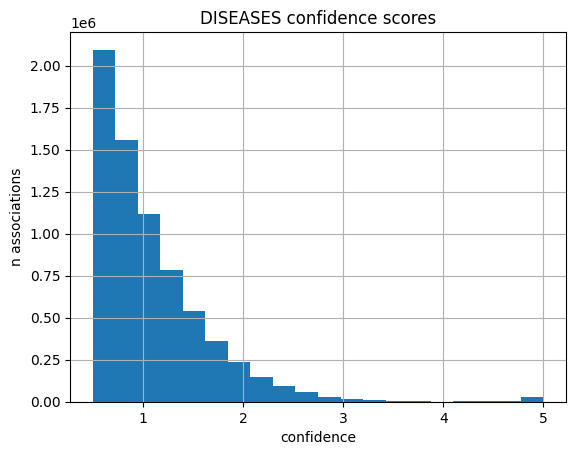

In [5]:
import matplotlib.pyplot as plt

print(diseases["conf"].describe())

diseases["conf"].hist(bins=20)
plt.xlabel("confidence"); plt.ylabel("n associations"); plt.title("DISEASES confidence scores")
plt.show()

Most of the mass sits below 2 stars (thin text-mining evidence). DISEASES' own documentation treats confidence ≥ 2 as the floor for a believable association, so we apply it before looking further.

In [6]:
MIN_CONF = 2.0

n_before = len(diseases)
diseases_conf = diseases[diseases["conf"] >= MIN_CONF].reset_index(drop=True)
print(f"{n_before:,} → {len(diseases_conf):,} rows with confidence >= {MIN_CONF}")

7,095,843 → 468,872 rows with confidence >= 2.0


We can now evaluate how many distinct diseases we have after the filtering of low confident genes and distinct genes associated to any disease.

In [7]:
print(f"{diseases_conf['doid'].nunique():,} distinct diseases")
print(f"{diseases_conf['gene_symbol'].nunique():,} distinct genes")

7,886 distinct diseases
14,540 distinct genes


#### Redundant diseases by gene size

Some entries are specific diseases with a handful of genes; others are broad umbrella terms from the Disease Ontology (e.g. "disease", "cancer") that list thousands. Worth seeing both ends.

In [8]:
genes_per_disease = (
    diseases_conf.groupby(["doid", "doid_name"])["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

genes_per_disease.describe()

count     7886.000000
mean        59.456252
std        312.122357
min          1.000000
25%          2.000000
50%          6.000000
75%         20.000000
max      10619.000000
Name: gene_symbol, dtype: float64

In [9]:
print("Largest gene sets:")
print(genes_per_disease.head(10))

print("\nSmallest gene sets:")
print(genes_per_disease.tail(10))

Largest gene sets:
doid          doid_name                        
DOID:4        Disease                              10619
DOID:7        Disease of anatomical entity          9033
DOID:630      Genetic disease                       5524
DOID:14566    Disease of cellular proliferation     5378
DOID:162      Cancer                                5263
DOID:863      Nervous system disease                5141
DOID:0050686  Organ system cancer                   4828
DOID:0050177  Monogenic disease                     4085
DOID:331      Central nervous system disease        3922
DOID:77       Gastrointestinal system disease       3816
Name: gene_symbol, dtype: int64

Smallest gene sets:
doid          doid_name                   
DOID:0050116  Tinea imbricata                 1
DOID:0050141  Intestinal botulism             1
DOID:0050490  Parenchymatous neurosyphilis    1
DOID:0050192  Nipah virus encephalitis        1
DOID:0050198  Chapare hemorrhagic fever       1
DOID:0050202  Lujo hemorrha

Diseases with very few genes carry too little signal, and diseases with thousands are Disease Ontology groupings (`Disease`, `Cancer`, `Genetic disease`, …) rather than specific diseases. We keep gene-set sizes in a reasonable range in between.

In [10]:
MIN_GENES_PER_DISEASE = 50
MAX_GENES_PER_DISEASE = 2000

too_small = genes_per_disease[genes_per_disease < MIN_GENES_PER_DISEASE]
too_large = genes_per_disease[genes_per_disease > MAX_GENES_PER_DISEASE]
keep_dois = genes_per_disease[
    (genes_per_disease >= MIN_GENES_PER_DISEASE) & (genes_per_disease <= MAX_GENES_PER_DISEASE)
].index.get_level_values("doid")

n_before = diseases_conf["doid"].nunique()
diseases_range = diseases_conf[diseases_conf["doid"].isin(keep_dois)].reset_index(drop=True)

print(f"dropped {len(too_small):,} diseases with < {MIN_GENES_PER_DISEASE} genes")
print(f"dropped {len(too_large):,} diseases with > {MAX_GENES_PER_DISEASE} genes, e.g. "
      + ", ".join(name for _, name in too_large.index[:5]))
print(f"\n{n_before:,} → {diseases_range['doid'].nunique():,} diseases kept")

dropped 6,904 diseases with < 50 genes
dropped 44 diseases with > 2000 genes, e.g. Disease, Disease of anatomical entity, Genetic disease, Disease of cellular proliferation, Cancer

7,886 → 938 diseases kept


#### Removing diseases with identical gene sets

Some DOIDs are near-synonyms that DISEASES' text mining cannot tell apart (e.g. "Leiomyosarcoma" and "Smooth muscle cancer") and end up with the exact same gene set under two different labels. We keep one representative per group of diseases sharing an identical gene set.

In [11]:
gene_sets = (
    diseases_range.groupby(["doid", "doid_name"])["gene_symbol"]
    .apply(frozenset)
    .reset_index()
)

dup_mask = gene_sets["gene_symbol"].duplicated(keep=False)
twin_groups = gene_sets[dup_mask].groupby("gene_symbol")["doid"].apply(list)

print(f"{dup_mask.sum():,} diseases in {len(twin_groups):,} groups share an identical gene set, e.g.:")
names_by_doid = gene_sets.set_index("doid")["doid_name"]
for dois in twin_groups.head(5):
    print("   " + " = ".join(names_by_doid.loc[dois]))

# one representative per group (the alphabetically first doid), the rest are dropped as duplicates
drop_dois = {doid for dois in twin_groups for doid in sorted(dois)[1:]}

n_before = diseases_range["doid"].nunique()
diseases_unique = diseases_range[~diseases_range["doid"].isin(drop_dois)].reset_index(drop=True)
print(f"\n{n_before:,} → {diseases_unique['doid'].nunique():,} diseases after dropping {len(drop_dois):,} twins")

36 diseases in 18 groups share an identical gene set, e.g.:
   Glycogen metabolism disorder = Glycogen storage disease
   Bile duct adenocarcinoma = Cholangiocarcinoma
   Insulinoma = Pancreatic cystadenoma
   Uveal cancer = Uveal melanoma
   Cystadenocarcinoma = Malignant cystadenoma

938 → 920 diseases after dropping 18 twins


We can also look into one specific disease. As an example, type 2 diabetes mellitus (`DOID:9352`) and its associated genes, ranked by confidence, are showcased.

In [12]:
doid = "DOID:9352"
example = diseases_unique[diseases_unique["doid"] == doid].sort_values("conf", ascending=False)

print(f"{example['doid_name'].iloc[0]}: {len(example)} associations, "
      f"{example['gene_symbol'].nunique()} distinct genes")
example.head(15)

Type 2 diabetes mellitus: 1117 associations, 1117 distinct genes


,gene_id,gene_symbol,doid,doid_name,conf
23783,ENSP00000240652,IAPP,DOID:9352,Type 2 diabetes mellitus,4.708
29359,ENSP00000252486,APOE,DOID:9352,Type 2 diabetes mellitus,4.670
158136,ENSP00000363827,HSPG2,DOID:9352,Type 2 diabetes mellitus,4.344
32777,ENSP00000255040,APCS,DOID:9352,Type 2 diabetes mellitus,4.337
185853,ENSP00000380432,INS,DOID:9352,Type 2 diabetes mellitus,4.000
196197,ENSP00000389814,ADIPOQ,DOID:9352,Type 2 diabetes mellitus,4.000
93795,ENSP00000312652,LEP,DOID:9352,Type 2 diabetes mellitus,4.000
195064,ENSP00000387662,GCG,DOID:9352,Type 2 diabetes mellitus,4.000
154168,ENSP00000362353,GLP1R,DOID:9352,Type 2 diabetes mellitus,4.000
84332,ENSP00000303830,INSR,DOID:9352,Type 2 diabetes mellitus,3.986


Let's save the filtered dataset with all disease-associated gene sets into our data folder.

In [13]:
diseases_unique.to_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t", index=False)

### Fetching protein-protein interaction networks from STRING

#### Setup

In [14]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"
STRING_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
print(f"{len(diseases):,} associations | {diseases['doid'].nunique():,} diseases | "
      f"{diseases['gene_id'].nunique():,} proteins")

260,212 associations | 920 diseases | 9,852 proteins


#### The STRING data

[STRING](https://string-db.org/) publishes one flat file of all pairwise interaction scores per species, so no API key needed either for this case. Each row is one (protein, protein) pair with a combined confidence score from 0 to 1000, aggregating evidence from experiments, curated databases, co-expression, text mining and more.

In [15]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest

STRING_URL = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
STRING_FILE = download_file(STRING_URL, STRING_DIR / "9606.protein.links.v12.0.txt.gz")

print(f"{STRING_FILE.name}: {STRING_FILE.stat().st_size / 1e6:.0f} MB")

9606.protein.links.v12.0.txt.gz: 83 MB


The dataframe has one row per interacting protein pair. STRING ids carry a species prefix (`9606.` for human), which we drop so they match the protein ids already in our disease table.

In [16]:
string_links = pd.read_csv(STRING_FILE, sep=" ", compression="gzip")
string_links["protein1"] = string_links["protein1"].str.removeprefix("9606.")
string_links["protein2"] = string_links["protein2"].str.removeprefix("9606.")
string_links.head()

,protein1,protein2,combined_score
0,ENSP00000000233,ENSP00000356607,173
1,ENSP00000000233,ENSP00000427567,154
2,ENSP00000000233,ENSP00000253413,151
3,ENSP00000000233,ENSP00000493357,471
4,ENSP00000000233,ENSP00000324127,201


As the DISEASES dataframe, we can also look into the amount of rows (protein interactions) and the columns type the dataframe has.

In [17]:
print(f"{len(string_links):,} rows")
print(string_links.dtypes)

13,715,404 rows
protein1          object
protein2          object
combined_score     int64
dtype: object


### Filtering interactions based on confidence score

#### High confidence interaction filter

The overall confidence score that is made aggregating every evidence channel of a protein-protein interaction in STRING is given by `combined_score` (its range is 0–1000). STRING's own "high confidence" cutoff is 700.

count    1.371540e+07
mean     2.686240e+02
std      1.569828e+02
min      1.500000e+02
25%      1.710000e+02
50%      2.090000e+02
75%      2.980000e+02
max      9.990000e+02
Name: combined_score, dtype: float64


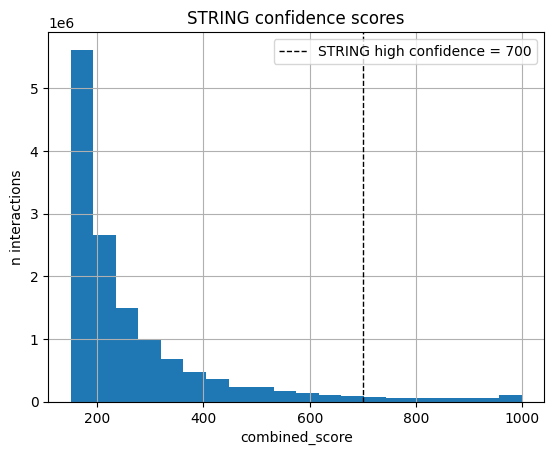

In [18]:
from matplotlib import pyplot as plt

print(string_links["combined_score"].describe())

string_links["combined_score"].hist(bins=20)
plt.axvline(700, color="k", ls="--", lw=1, label="STRING high confidence = 700")
plt.xlabel("combined_score"); plt.ylabel("n interactions"); plt.title("STRING confidence scores")
plt.legend(); plt.show()

We keep only high-confidence interactions (`combined_score >= 700`, STRING's own "high confidence" band). Medium confidence (`>= 400`) would keep far more edges, but pulls in a lot of weaker, text-mining-only evidence — and we're already leaning on DISEASES' text-mined associations for the disease genes, so keeping the network side clean avoids compounding two noisy sources.

In [19]:
STRING_MIN_SCORE = 700

n_before = len(string_links)
string_links = string_links[string_links["combined_score"] >= STRING_MIN_SCORE].reset_index(drop=True)
print(f"{n_before:,} → {len(string_links):,} interactions with combined_score >= {STRING_MIN_SCORE}")

13,715,404 → 473,860 interactions with combined_score >= 700


We can evaluate how many unique proteins and interactions we end up on the final set.

In [20]:
n_proteins = pd.concat([string_links["protein1"], string_links["protein2"]]).nunique()
print(f"{n_proteins:,} distinct proteins")
print(f"{len(string_links):,} interactions")

16,201 distinct proteins
473,860 interactions


#### Interactions per protein

Like the disease gene sets, this is heavy-tailed: most proteins have a handful of high-confidence partners, while a few hub proteins have thousands.

In [21]:
interactions_per_protein = (
    pd.concat([string_links["protein1"], string_links["protein2"]])
    .value_counts()
)

print(interactions_per_protein.describe())
print("\nMost connected proteins:")
print(interactions_per_protein.head(10))

count    16201.000000
mean        58.497624
std         91.458814
min          2.000000
25%          8.000000
50%         26.000000
75%         70.000000
max       1532.000000
Name: count, dtype: float64

Most connected proteins:
ENSP00000269305    1532
ENSP00000272317    1178
ENSP00000388107    1042
ENSP00000275493    1012
ENSP00000495360     930
ENSP00000244537     904
ENSP00000333277     904
ENSP00000494750     876
ENSP00000451828     870
ENSP00000431822     846
Name: count, dtype: int64


As an example, `INS` (insulin, `ENSP00000380432`) — one of the type 2 diabetes genes from before — and its highest-confidence interaction partners.

In [22]:
protein = "ENSP00000380432"
example = string_links[(string_links["protein1"] == protein) | (string_links["protein2"] == protein)]
example = example.sort_values("combined_score", ascending=False)

print(f"{protein}: {len(example)} interactions")
example.head(15)

ENSP00000380432: 612 interactions


,protein1,protein2,combined_score
340952,ENSP00000380432,ENSP00000265986,999
464646,ENSP00000497069,ENSP00000380432,999
340994,ENSP00000380432,ENSP00000304895,999
340899,ENSP00000380432,ENSP00000376637,999
146811,ENSP00000303830,ENSP00000380432,999
340900,ENSP00000380432,ENSP00000497069,999
341026,ENSP00000380432,ENSP00000303830,999
91784,ENSP00000265986,ENSP00000380432,999
327055,ENSP00000376637,ENSP00000380432,999
341059,ENSP00000380432,ENSP00000295897,999


We can save these protein-protein interactions on our data folder.

In [23]:
string_links.to_csv(DATA_DIR / "string_filtered.tsv", sep="\t", index=False)

## Disease-associated protein-protein interaction networks

### Building the networks

#### Setup

In [4]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/diseases")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")

print(f"{diseases['doid'].nunique():,} diseases | {diseases['gene_id'].nunique():,} disease genes")
print(f"{len(string_links):,} interactions | "
      f"{pd.concat([string_links['protein1'], string_links['protein2']]).nunique():,} proteins")

920 diseases | 9,852 disease genes
473,860 interactions | 16,201 proteins


#### Disease graphs construction

For each disease, the network is the **induced subgraph** of STRING restricted to that disease's associated genes: nodes are the disease genes, edges are the high-confidence STRING interactions between them. No 1-hop expansion — only interactions where both proteins are already disease genes.

We build the full STRING graph once, then take one induced subgraph per disease out of it.

In [5]:
import networkx as nx

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")
print(f"{G_string.number_of_nodes():,} nodes | {G_string.number_of_edges():,} edges")

gene_sets = diseases.groupby(["doid", "doid_name"])["gene_id"].apply(set)

disease_graphs = {}
rows = []
for (doid, doid_name), genes in gene_sets.items():
    G = G_string.subgraph(genes)
    disease_graphs[doid] = G
    rows.append({"doid": doid, "doid_name": doid_name,
                 "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})

graph_sizes = pd.DataFrame(rows).sort_values("n_nodes", ascending=False)
print(f"\n{len(disease_graphs):,} disease networks built")

16,201 nodes | 236,930 edges

920 disease networks built


#### Network sizes

Genes with no high-confidence partner among the *other* disease genes end up isolated in a disease's
own network, so node and edge counts shrink further from the raw gene-set sizes.

In [6]:
print(graph_sizes[["n_nodes", "n_edges"]].describe())

print("\nLargest networks:")
print(graph_sizes.head(10).to_string(index=False))

print("\nSmallest networks:")
print(graph_sizes.tail(10).to_string(index=False))

           n_nodes       n_edges
count   920.000000    920.000000
mean    269.680435   3798.123913
std     340.604238   6299.163262
min      46.000000     39.000000
25%      70.750000    373.750000
50%     126.000000    936.500000
75%     285.250000   3838.500000
max    1880.000000  33068.000000

Largest networks:
        doid                        doid_name  n_nodes  n_edges
    DOID:612 Primary immunodeficiency disease     1880    32324
   DOID:4194       Glucose metabolism disease     1866    31100
     DOID:18           Urinary system disease     1800    31866
    DOID:409                    Liver disease     1796    33068
   DOID:9351                Diabetes mellitus     1793    29858
    DOID:417               Autoimmune disease     1790    30936
DOID:0050155           Sensory system disease     1776    25143
DOID:0050615        Respiratory system cancer     1610    30783
DOID:0050737      Autosomal recessive disease     1602    21580
   DOID:5614                      Eye diseas

Back to type 2 diabetes mellitus (`DOID:9352`) we have been using as an example, its network alongside its raw gene set is showcased.

In [7]:
doid = "DOID:9352"
G = disease_graphs[doid]
n_genes = diseases.loc[diseases["doid"] == doid, "gene_id"].nunique()

print(f"Type 2 diabetes mellitus: {n_genes} disease genes → "
      f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges in the network")

Type 2 diabetes mellitus: 1117 disease genes → 1072 nodes, 16234 edges in the network
